# Hacking Senegal & Ethiopia Food and Nutrition Project

## Introduction
This is a compiled notebook containing all parts of the code notebook for this project. We first computed the Food Demand System for our selected countries, Senegal & Ethiopia, during the 2018-2019 period. Then, we computed their Nutrition System followed with some analyses on Policy Goals.

## Installation and Importations

Please make sure the requirements text files are available in your local directory if you're running locally, and uncomment the code to install all necessary libraries. Then run the code block followed by the installation code to make sure you imported all the required libraries for our project code.

In [2]:
%pip install -r requirements-estimation.txt

  Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached cfedemands-0.8.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached ligonlibrary-0.2.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached consumerdemands-0.5.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached gspread_pandas-3.3.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached python_gnupg-0.5.6-py2.py3-none-any.whl.metadata (2.1 kB)
  Using cached python_magic-0.4.27-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached thefuzz-0.22.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached rapidfuzz-3.14.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
Using cached pandas-3.0.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.3 MB)
Using cached cfedemands-0.8.2-py3-none-any.whl (98 kB)
Using cached ligonlibrary-0.2.0-py3-none-any.whl (19 kB)
Using cached consumerdemands-0.5.0-py3-none-any.whl (14 kB)
Using cached gspread_pan

In [3]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
from eep153_tools.sheets import read_sheets
import pandas as pd
import numpy as np
from cfe import Regression
import matplotlib.pyplot as plt
import cfe.regression as rgsn

## Food Demand Estimation System

In this section, we compare household food demand in Senegal and Ethiopia during the 2018-2019 period. Its purpose is to estimate how household food spending changes across food categories and how demand is related to household characteristics like household size, age structure, and gender composition.

$\textbf{Populations of Interest:}$ 
 Senegal & Ethiopia

Time frame : 2018-2019

In [5]:
Senegal_URL = "https://docs.google.com/spreadsheets/d/1s01A3lSZdlcHQPIfJcLdI3k-NtQkTInia1fDAg7W5eQ/edit?gid=1254962063#gid=1254962063"
Ethiopia_URL = "https://docs.google.com/spreadsheets/d/1qOZi1FqAS89x461pCIgwRaAfpBw5aUp7kBbp0tQKI_E/edit?gid=790992172#gid=790992172" 

### Data Preparation

In [6]:
def prepare_data(URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(URL, sheet = FE_Sheet)
    d = read_sheets(URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = np.log(x)

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

#### Senegal Data

In [7]:
S18_y, S18_d = prepare_data(Senegal_URL, "Food Expenditures (2018)")
S19_y, S19_d = prepare_data(Senegal_URL, "Food Expenditures (2019)")

SE_y = pd.concat([S18_y, S19_y])
SE_d = pd.concat([S18_d, S19_d])

In [8]:
SE_y.head()

,,j,"Abats et tripes (foie, rognon, etc.)",Ail,Ananas,Arachide grillée,Arachides décortiquées ou pilées (noflaye),Arachides fraîches en coques,Arachides séchées en coques,"Arôme (Maggi, Jumbo, etc.)",Attiéke,"Aubergine, Courge/Courgette",...,Viande de b__uf,Viande de chameau,Viande de chèvre,Viande de mouton,Viande de porc,Viande de poulet,Vinaigre /moutarde,Autres produits laitiers,"Gari, tapioca",Gibiers
i,t,m,,,,,,,,,,,,,,,,,,,,,
112,2018,dakar,NaN,6.620073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.55108,...,7.863267,NaN,NaN,NaN,NaN,8.101678,6.396930,NaN,NaN,NaN
113,2018,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,2018,dakar,NaN,6.907755,NaN,NaN,NaN,5.703782,NaN,NaN,NaN,4.60517,...,NaN,NaN,NaN,NaN,NaN,NaN,7.170120,NaN,NaN,NaN
132,2018,dakar,NaN,5.521461,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.006368,NaN,NaN,NaN,NaN,7.824046,6.214608,NaN,NaN,NaN
133,2018,dakar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


when taking th median there should be something to ignore the Nan values so it doesnt error. 

#### Ethiopia Data

In [10]:
ET_y, ET_d = prepare_data(Ethiopia_URL, "Food Expenditures (2018-19)")

In [11]:
ET_y.head()

j                              Avocado  Banana  Barley  Beef      Beer  \
i            t       m                                                   
1.203020e+13 2018-19 gambela       NaN     NaN     NaN   NaN  4.276666   
1.010109e+16 2018-19 tigray        NaN     NaN     NaN   NaN       NaN   
                     tigray        NaN     NaN     NaN   NaN       NaN   
                     tigray   2.564949     NaN     NaN   NaN       NaN   
                     tigray        NaN     NaN     NaN   NaN       NaN   

j                             Beetroot   Berbere  Boye/Yam  Bread/biscuit  \
i            t       m                                                      
1.203020e+13 2018-19 gambela  4.382027  2.995732       NaN            NaN   
1.010109e+16 2018-19 tigray        NaN       NaN       NaN            NaN   
                     tigray        NaN  1.945910       NaN            NaN   
                     tigray        NaN  3.583519       NaN       2.564949   
                     tigray        NaN       NaN       NaN            NaN   

j                             Bula  ...  Sorghum     Sugar  Sun Flower  \
i            t       m              ...                                  
1.203020e+13 2018-19 gambela   NaN  ...  1.94591  3.295837         NaN   
1.010109e+16 2018-19 tigray    NaN  ...      NaN  2.484907         NaN   
                     tigray    NaN  ...      NaN  2.079442         NaN   
                     tigray    NaN  ...      NaN  3.178054         NaN   
                     tigray    NaN  ...      NaN  3.912023         NaN   

j                             Sweet potato       Tea      Teff  Tella  \
i            t       m                                                  
1.203020e+13 2018-19 gambela           NaN       NaN  5.192957    NaN   
1.010109e+16 2018-19 tigray            NaN       NaN       NaN    NaN   
                     tigray            NaN       NaN       NaN    NaN   
                     tigray            NaN  1.791759       NaN    NaN   
                     tigray            NaN  1.609438       NaN    NaN   

j                              Tomato     Vetch  Wheat  
i            t       m                                  
1.203020e+13 2018-19 gambela      NaN  3.332205    NaN  
1.010109e+16 2018-19 tigray       NaN       NaN    NaN  
                     tigray       NaN       NaN    NaN  
                     tigray   2.70805       NaN    NaN  
                     tigray       NaN       NaN    NaN  

[5 rows x 73 columns]

### Estimation


Let $y_i^j$ be log expendicture on food $j$ by household $i$ at a particular time. We want to estimate a regression that takes the form: 

$y_i^j = A^j(p) + \gamma_j' d_i + \beta_j w_i + \zeta_i^j$
-

In [12]:
# Senegal First 

SE_y = SE_y.stack().dropna()
SE_d = SE_d.stack().dropna()

SE_y = SE_y.groupby(level=['i', 't', 'm', 'j']).first()
SE_d = SE_d.groupby(level=['i', 't', 'm', 'k']).first()

assert SE_y.index.names == ['i','t','m','j']
assert SE_d.index.names == ['i','t','m','k']

#Ethiopia Next
ET_y = ET_y.stack().dropna()

ET_d = ET_d.stack().dropna()

# Check that indices are in right places!
assert ET_y.index.names == ['i','t','m','j']
assert ET_d.index.names == ['i','t','m','k']

In [13]:
#note this may take awhile to run
SE_result = Regression(y = SE_y,d = SE_d)
SE_result.predicted_expenditures()

i       t     m        j                                                                  
112     2018  dakar    Ail                                                                     577.701198
                       Arachides décortiquées ou pilées (noflaye)                              396.552597
                       Arôme (Maggi, Jumbo, etc.)                                              183.316015
                       Aubergine, Courge/Courgette                                             238.542067
                       Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     150.336375
                                                                                                 ...     
259812  2019  sedhiou  Thé                                                                     147.491146
                       Tomate fraîche                                                          124.069691
                       Viande de b__uf                       

In [14]:
ET_result = Regression(y = ET_y,d = ET_d)
ET_result.predicted_expenditures()

i             t        m          j       
1.203020e+13  2018-19  gambela    Banana       25.051831
                                  Barley       56.200355
                                  Beef        198.802206
                                  Beetroot     18.980373
                                  Berbere      50.183540
                                                 ...    
1.501011e+17  2018-19  dire dawa  Sugar        57.326793
                                  Tea          24.625439
                                  Teff        199.872083
                                  Tomato       78.228481
                                  Wheat        67.650493
Length: 178737, dtype: float64

#### Interpretation of Results

These predicted expenditures are fitted values from the demand model. They estimate how much each household is expected to spend on each food item based on the household’s total food budget and demographic characteristics. The results can now be used to calculate total household food budgets, reference budgets, food quantities, and demand curves. Since the predictions are indexed by household, year, market, and food item, they allow us to compare food demand patterns across countries and across household types.

The Senegal model produces more predicted expenditure observations than Ethiopia, with 409,374 predicted household-food values compared to 178,737 for Ethiopia. This likely reflects differences in the number of households, food categories, or years included in each dataset. Senegal combines 2018 and 2019 food expenditure data, while Ethiopia uses a single 2018-19 period. The predicted values show household-level variation in spending across foods, markets, and time.

### Understanding Function Parameters

#### Senegal $\beta$ Parameters - (Relative) Income Elasticity

$\beta$ coefficients govern how income elastic different goods are (higher values means more elastic). These are also called Frisch elasticities

In [15]:
SE_result.get_beta().sort_values()

j
Salade (laitue, batavia, etc.)                                         0.493232
Pain moderne                                                           0.499100
Poisson frais yaboy ou obo (sardinelle)                                0.742341
Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)    0.754337
Boissons gazeuses (coca, etc.)                                         0.790009
                                                                         ...   
Mayonnaise                                                             2.715955
Lait en poudre                                                         2.762030
Riz local brisé                                                        2.825304
Oignon frais                                                           2.843728
Huile de soja / végétale (e.g., Ninaal, Jaara, etc.)                   3.461998
Name: beta, Length: 63, dtype: float64

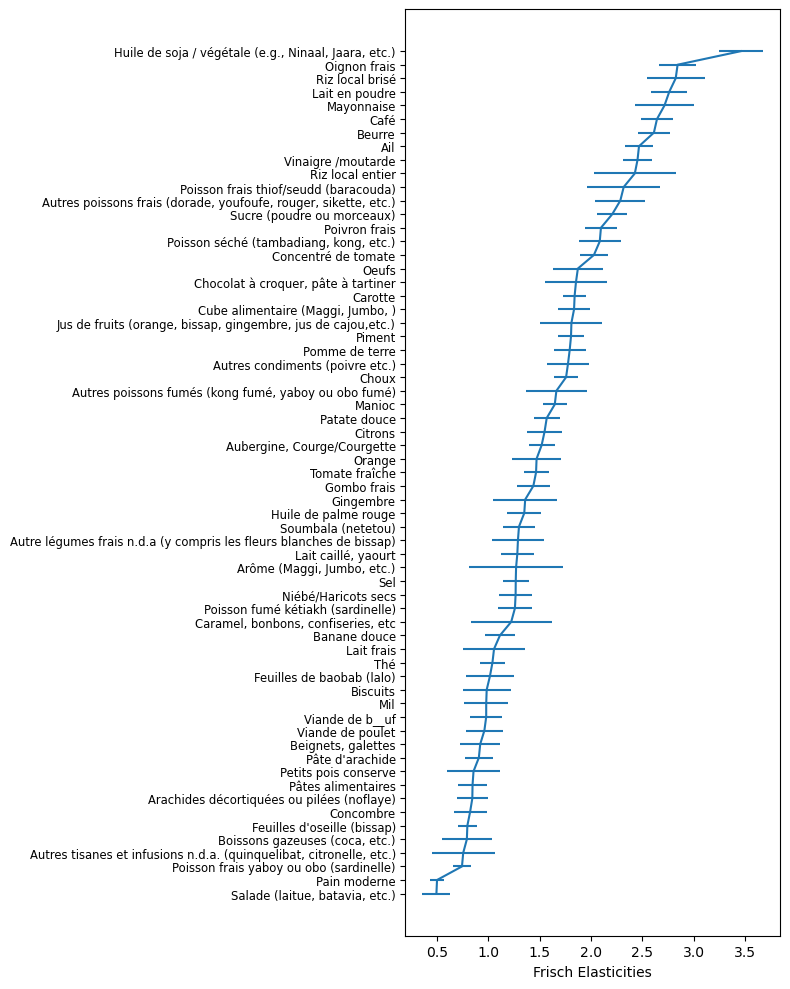

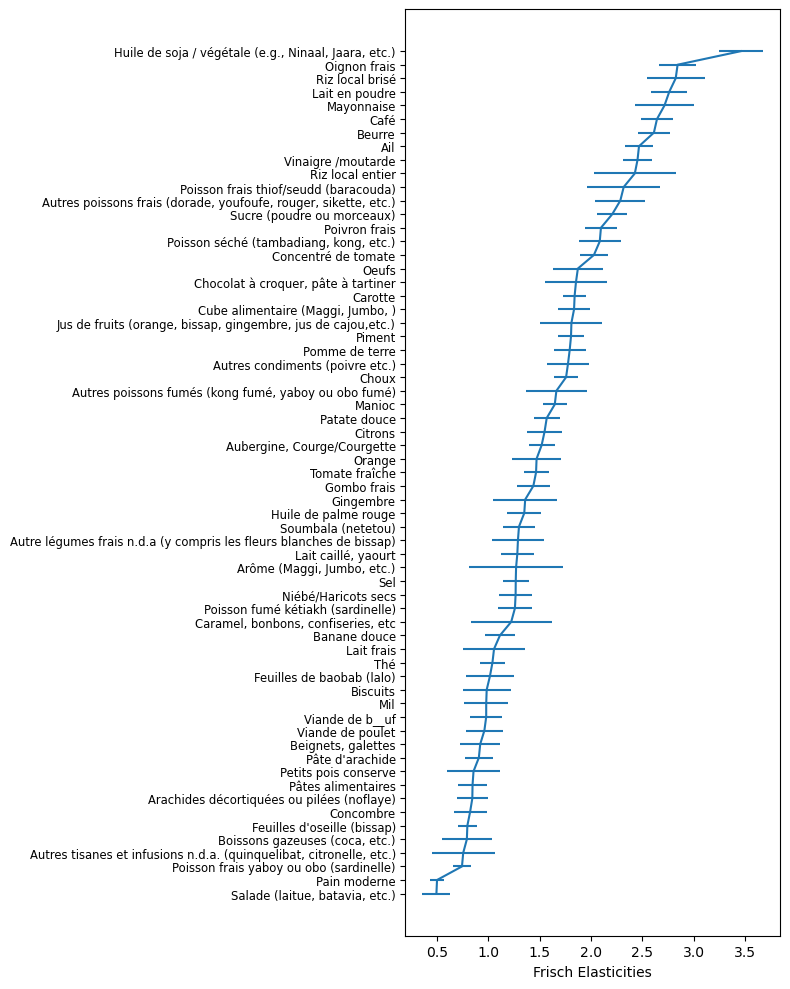

In [16]:
SE_result.graph_beta()

$\textbf{Interpretation of $\beta$ values}$

Goods with higher $\beta$ values are more responsive to household food budgets, while goods with lower $\beta$ values are less responsive. This means that when a household has more resources to spend on food, it tends to increase spending more on goods with higher $\beta$ values.

Some specific examples from Senegal:
- Vegetable/soy oil ($\beta \approx 3.46$), fresh onions ($\beta \approx 2.84$), and local broken rice ($\beta \approx 2.83$) are among the most income-responsive goods, meaning spending on these tends to rise more as household food budgets increase.
- Powdered milk ($\beta \approx 2.76$) and mayonnaise ($\beta \approx 2.72$) are also highly responsive, suggesting these goods become more important in household spending as resources increase.
- Salad ($\beta \approx 0.49$) and modern bread ($\beta \approx 0.50$) are among the least income-responsive goods, meaning spending on these changes less as household food budgets rise.
- Fresh sardine/yaboy fish ($\beta \approx 0.74$), herbal teas/infusions ($\beta \approx 0.75$), and soft drinks ($\beta \approx 0.79$) are also relatively less responsive compared to other foods in the Senegal model.

#### Ethiopia beta parameters - relative income elasticity 

In [17]:
ET_result.get_beta().sort_values()

j
Orange                0.574330
Linseed               0.602050
Field Pea             0.636296
Beetroot              0.672352
Beef                  0.738104
Injera                0.740898
Maize                 0.745924
Eggs                  0.817667
Soda                  0.853092
Banana                0.870121
Mango                 0.876788
Teff                  0.902003
Butter/ghee           0.906619
Coffee                0.909914
Salt                  0.913509
Wheat                 0.923774
Carrot                0.929539
Barley                0.943240
Garlic                0.943845
Chick Pea             0.946828
Horsebeans            0.979381
Fenugreek             0.985264
Leafy Greens          0.993061
Shiro                 0.994459
Goat & mutton meat    1.046676
Kariya                1.047869
Lentils               1.069848
Potato                1.109185
Berbere               1.109600
Oils                  1.114045
Pasta/Macaroni        1.134188
Sugar                 1.143998
Milk  

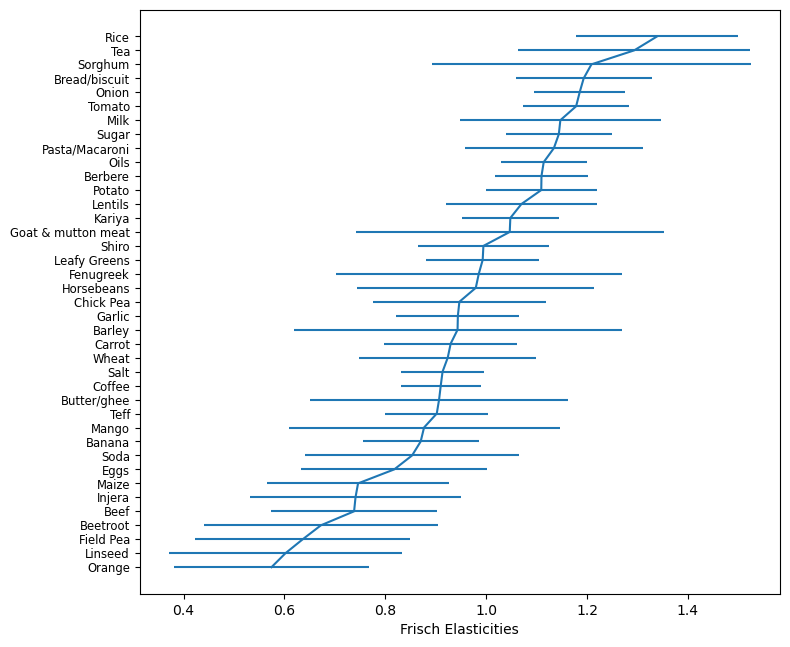

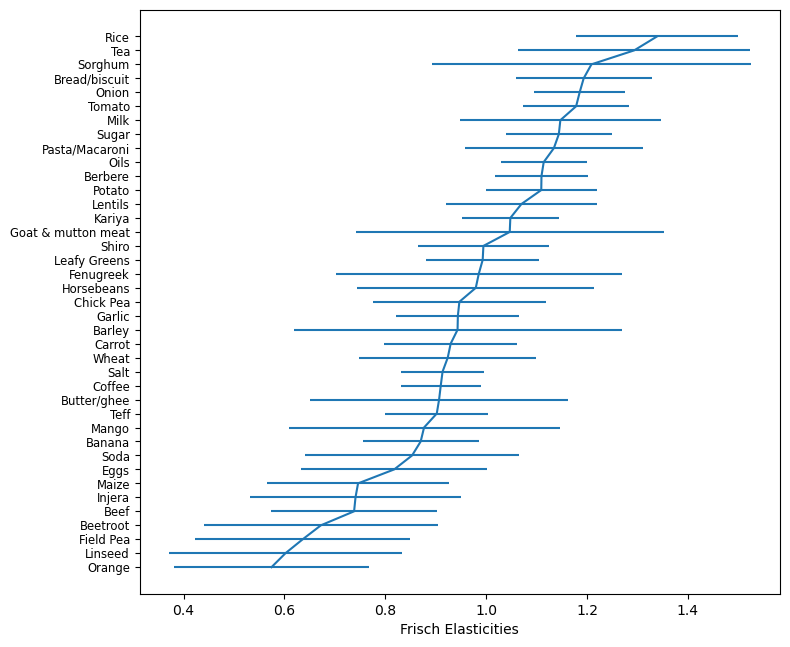

In [18]:
ET_result.graph_beta()

$\textbf{Interpretation of $\beta$ values}$

Goods with higher $\beta$ values are more responsive to household food budgets, while goods with lower $\beta$ values are less responsive. This means that when a household has more resources to spend on food, it tends to increase spending more on goods with higher $\beta$ values.

Some specific examples from Ethiopia:

- Rice ($\beta \approx 1.34$), Tea ($\beta \approx 1.29$), and Sorghum ($\beta \approx 1.21$) are among the most income-responsive goods, meaning spending on these tends to rise more as household food budgets increase.
- Bread/biscuit ($\beta \approx 1.19$), Onion ($\beta \approx 1.19$), and Tomato ($\beta \approx 1.18$) are also relatively income-responsive, suggesting these goods become more important in household spending as resources increase.
- Orange ($\beta \approx 0.57$), Linseed ($\beta \approx 0.60$), and Field Pea ($\beta \approx 0.64$) are among the least income-responsive goods, meaning spending on these changes less as household food budgets rise.
- Beetroot ($\beta \approx 0.67$), Beef ($\beta \approx 0.74$), and Injera ($\beta \approx 0.74$) are also relatively less responsive compared to other foods in the Ethiopia model.

#### Senegal $\gamma$ parameters - Demand and Household Composition

$\gamma$ parameters in the regression are the effects of household composition on demand.

In [19]:
SE_result.gamma

k,Females 00-03,Females 04-08,Females 09-13,Females 14-18,Females 19-30,Females 31-50,Females 51-99,Males 00-03,Males 04-08,Males 09-13,Males 14-18,Males 19-30,Males 31-50,Males 51-99,boys,girls,log HSize,men,women,Constant
j,,,,,,,,,,,,,,,,,,,,
Ail,-0.240425,-0.243685,-0.213915,-0.228702,-0.255420,-0.189833,-0.216282,0.047162,0.093381,0.077845,0.103592,0.143385,0.160847,0.167134,-0.100439,0.206222,-0.089726,-0.118539,0.312986,4.251510
Arachides décortiquées ou pilées (noflaye),-0.026332,0.027044,0.051420,-0.022900,-0.026553,0.040702,0.027188,0.139290,0.174543,0.149337,0.138169,0.099136,0.135060,0.113436,-0.112674,0.012574,-0.103889,-0.068274,0.053856,5.379838
"Arôme (Maggi, Jumbo, etc.)",-0.073534,0.009865,0.009019,0.004874,-0.067986,-0.010615,0.143944,-0.042904,0.000704,0.088072,0.028269,-0.026145,0.039969,-0.138758,-0.020769,-0.074662,0.007694,-0.031417,0.086751,4.521189
"Aubergine, Courge/Courgette",-0.302826,-0.323324,-0.314838,-0.321236,-0.260743,-0.235549,-0.235414,0.041748,0.057133,0.047862,0.016443,0.027907,0.029284,0.091856,-0.030667,0.319268,-0.045147,0.007778,0.301839,4.516615
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),-0.515903,-0.555592,-0.437303,-0.466001,-0.487716,-0.448157,-0.486905,0.061273,0.006416,0.025034,-0.015592,-0.090702,-0.014731,0.110561,-0.052416,0.504490,-0.046014,0.133367,0.481464,4.247507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Thé,-0.455556,-0.443569,-0.462866,-0.495050,-0.485856,-0.452337,-0.479347,0.011725,0.040960,0.012318,0.040284,0.032855,0.063929,0.092418,-0.016994,0.477810,-0.030701,-0.021891,0.480428,5.053929
Tomate fraîche,-0.260368,-0.269420,-0.253087,-0.267679,-0.303099,-0.244429,-0.258763,0.365057,0.330010,0.338768,0.376817,0.321831,0.402229,0.396065,-0.357980,0.256941,-0.124567,-0.311895,0.339612,4.871820
Viande de b__uf,-0.100132,-0.102297,-0.074192,-0.095860,-0.088710,-0.046738,-0.064069,-0.023003,-0.006523,-0.013711,0.025483,-0.028691,0.017112,0.064044,-0.002315,0.082281,0.088704,0.034618,0.113448,7.830253


$\textbf{Interpretation of $\gamma$ values}$

Positive $\gamma$ values mean that having more people in that household group is associated with higher predicted demand for that food. Negative $\gamma$ values mean that having more people in that household group is associated with lower predicted demand for that food, holding the rest of the model constant.

Some specific examples from Senegal:
- Vinaigre/moutarde has large positive $\gamma$ values across many age groups, such as females 00-03 ($\gamma \approx 0.85$), males 00-03 ($\gamma \approx 0.90$), and males 09-13 ($\gamma \approx 0.96$). This suggests that larger households with children are associated with higher predicted demand for this condiment category.
- Autres légumes frais has negative values for many female age groups, such as females 00-03 ($\gamma \approx -0.52$), females 04-08 ($\gamma \approx -0.56$), and females 19-30 ($\gamma \approx -0.49$). This means that, in the model, households with more people in these groups are associated with lower predicted spending on this category.
- Tomate fraîche has positive values for several male groups, such as males 00-03 ($\gamma \approx 0.37$), males 04-08 ($\gamma \approx 0.33$), and males 31-50 ($\gamma \approx 0.40$). This suggests tomato demand may increase in households with more males in these groups.
- Ail has negative values for many female age groups but positive values for many male age groups. For example, females 00-03 has $\gamma \approx -0.24$, while males 31-50 has $\gamma \approx 0.16$. This suggests that the relationship between household composition and garlic demand differs by gender and age group.

#### Ethiopia $\gamma$ parameters - Demand and Household Composition 

In [21]:
ET_result.gamma

k,Females 00-03,Females 04-08,Females 09-13,Females 14-18,Females 19-30,Females 31-50,Females 51-99,Males 00-03,Males 04-08,Males 09-13,Males 14-18,Males 19-30,Males 31-50,Males 51-99,log HSize,Constant
j,,,,,,,,,,,,,,,,
Banana,-0.001071,-0.175543,-0.037868,0.003595,0.132192,0.193383,0.146664,0.036254,-0.147273,-0.094812,-0.142671,0.074057,0.340116,-0.002037,0.091681,3.214252
Barley,-0.094529,-0.136153,0.163121,-0.050965,-0.070221,-0.015748,-0.050618,-0.118648,-0.004763,-0.018166,0.044505,0.006059,-0.127048,0.195777,0.455288,3.387545
Beef,-0.110734,-0.125741,-0.051287,0.117338,0.087114,0.115333,0.023069,0.041705,-0.032652,-0.095356,-0.044840,0.022216,0.110304,0.196821,0.188416,5.362452
Beetroot,-0.127499,-0.101845,0.038650,0.016060,-0.022292,-0.039585,-0.101455,-0.008334,0.048521,-0.017601,0.023464,0.046988,0.119662,-0.002856,0.188675,2.667313
Berbere,-0.070658,-0.143898,-0.059576,-0.029654,0.098859,0.162326,0.031985,-0.013843,-0.080151,-0.077777,-0.077777,0.018449,0.142148,-0.130207,0.134362,3.421622
Bread/biscuit,-0.098719,-0.229843,-0.037526,-0.116170,-0.008764,0.027452,0.030307,-0.112059,-0.117920,-0.041775,-0.051662,0.016955,0.121538,-0.078199,0.413486,3.488076
Butter/ghee,0.010905,-0.104066,-0.098858,0.082645,-0.032167,-0.147684,0.090096,0.004913,-0.220568,-0.067262,-0.045891,-0.136391,0.025312,0.053187,0.344748,4.113371
Carrot,-0.138484,-0.040377,0.006233,0.157819,0.083223,0.092598,-0.013127,-0.060630,0.035792,-0.004082,-0.041919,-0.006180,0.168384,0.040852,0.100859,2.709710
Chick Pea,-0.138732,-0.026845,0.097464,-0.010169,0.014004,0.005877,0.060118,-0.083174,0.010493,0.040246,0.004321,0.001722,0.023617,0.063618,0.262837,3.348215


$\textbf{Interpretation of $\gamma$ values}$

Positive $\gamma$ values mean that having more people in that household group is associated with higher predicted demand for that food. Negative $\gamma$ values mean that having more people in that household group is associated with lower predicted demand for that food, holding the rest of the model constant.

Some specific examples from Ethiopia:

- Maize has a large positive $\gamma$ value for log household size ($\gamma \approx 0.50$), meaning larger households are associated with higher predicted demand for maize. This makes sense because maize can function as a staple food for many households.
- Barley also has a positive value for log household size ($\gamma \approx 0.46$), suggesting that larger households are associated with greater predicted spending on barley.
- Bread/biscuit has a positive value for log household size ($\gamma \approx 0.41$), meaning predicted demand tends to increase as household size rises.
- Eggs has a very small value for log household size ($\gamma \approx 0.01$), meaning household size does not appear to strongly affect predicted egg demand in this model.
- Linseed has negative values for some household composition variables, such as Males 00-03 ($\gamma \approx -0.06$), but positive values for others, such as Females 19-30 ($\gamma \approx 0.27$) and Males 19-30 ($\gamma \approx 0.30$). This suggests that the relationship between household composition and linseed demand differs by age and gender group.

### Demand Function Analysis


#### Predicted expenditures

In [22]:
#saving results to variable for later use
SE_xhat = SE_result.predicted_expenditures()
ET_xhat = ET_result.predicted_expenditures()

This gives the model’s predicted spending for each household and food item.

### Reference Prices 

#### Senegal pbar - reference prices

This creates one average price for each food.

In [23]:
SE_prices18 = read_sheets(Senegal_URL, sheet="Food Prices (2018)")
SE_prices19 = read_sheets(Senegal_URL, sheet="Food Prices (2019)")

SE_prices = pd.concat([SE_prices18, SE_prices19])

SE_prices['t'] = SE_prices['t'].astype(str).str.strip()
SE_prices['m'] = SE_prices['m'].astype(str).str.strip().str.lower()
SE_prices['j'] = SE_prices['j'].astype(str).str.strip()
SE_prices['Price'] = pd.to_numeric(SE_prices['Price'], errors='coerce')

SE_prices = SE_prices.pivot_table(
    index=['t', 'm'],
    columns='j',
    values='Price',
    aggfunc='mean'
)

SE_pbar = SE_prices.xs('2019', level='t').mean()
SE_pbar = SE_pbar.reindex(SE_result.beta.index).dropna()

SE_pbar

j
Ail                                                                     277.107143
Arachides décortiquées ou pilées (noflaye)                              304.270833
Arôme (Maggi, Jumbo, etc.)                                              244.642857
Aubergine, Courge/Courgette                                             149.702381
Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)     193.630952
                                                                          ...     
Thé                                                                     483.556548
Tomate fraîche                                                          195.541383
Viande de b__uf                                                        2316.071429
Viande de poulet                                                       2716.071429
Vinaigre /moutarde                                                      297.088176
Length: 63, dtype: float64

#### Ethiopia pbar - reference prices
 
This creates one average price for each food.

In [24]:
ET_prices = read_sheets(Ethiopia_URL, sheet="Food Prices (2018-19)")

ET_prices['t'] = ET_prices['t'].astype(str).str.strip()
ET_prices['m'] = ET_prices['m'].astype(str).str.strip().str.lower()
ET_prices['j'] = ET_prices['j'].astype(str).str.strip()
ET_prices['Price'] = pd.to_numeric(ET_prices['Price'], errors='coerce')

ET_prices = ET_prices.pivot_table(
    index=['t', 'm'],
    columns='j',
    values='Price',
    aggfunc='mean'
)

ET_pbar = ET_prices.xs('2018-19', level='t').mean()
ET_pbar = ET_pbar.reindex(ET_result.beta.index).dropna()

ET_pbar

j
Banana                 33.191064
Barley                 29.740652
Beef                  259.965623
Beetroot               25.559157
Berbere                98.895659
Bread/biscuit          34.232332
Butter/ghee           285.186818
Carrot                 24.974313
Chick Pea              38.412494
Coffee                138.261190
Eggs                   22.638552
Fenugreek              76.380772
Field Pea              35.402901
Garlic                109.290470
Goat & mutton meat    309.517002
Horsebeans             35.830183
Injera                 47.001451
Kariya                 25.534222
Leafy Greens           19.849968
Lentils                65.527887
Linseed                56.670138
Maize                  16.433072
Mango                  23.863109
Milk                   42.640130
Oils                   78.458923
Onion                  35.765287
Orange                 33.680698
Pasta/Macaroni         38.678915
Potato                 17.802693
Rice                   30.221712
Salt    

### Budgets 

This adds up predicted food spending for each household, then finds the median household food budget.

In [25]:
# Total food expenditures per household
SE_xbar = SE_xhat.groupby(['i', 't', 'm']).sum()
ET_xbar = ET_xhat.groupby(['i', 't', 'm']).sum()

# Reference budget: median household
SE_xref = SE_xbar.quantile(0.5)
ET_xref = ET_xbar.quantile(0.5)

print("Senegal median food budget:", SE_xref)
print("Ethiopia median food budget:", ET_xref)

Senegal median food budget: 49427.36179672777
Ethiopia median food budget: 1907.5180601682002


#### Food Quantities
- 
This converts predicted spending into predicted quantities.

In [26]:
#Senegal First
SE_qhat = (SE_xhat.unstack('j')/SE_pbar).dropna(how='all')

# Drop missing columns
SE_qhat = SE_qhat.loc[:,SE_qhat.count()>0]

SE_qhat

,,j,Ail,Arachides décortiquées ou pilées (noflaye),"Arôme (Maggi, Jumbo, etc.)","Aubergine, Courge/Courgette",Autre légumes frais n.d.a (y compris les fleurs blanches de bissap),Autres condiments (poivre etc.),"Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)","Autres poissons fumés (kong fumé, yaboy ou obo fumé)","Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)",Banane douce,...,Riz local entier,"Salade (laitue, batavia, etc.)",Sel,Soumbala (netetou),Sucre (poudre ou morceaux),Thé,Tomate fraîche,Viande de b__uf,Viande de poulet,Vinaigre /moutarde
i,t,m,,,,,,,,,,,,,,,,,,,,,
112,2018,dakar,2.084758,1.303288,0.749321,1.593442,0.776407,0.176746,5.333878,2.624926,1.818128,2.364299,...,5.945752,1.542816,0.697593,0.641896,3.527760,0.674189,1.991816,1.709252,2.107129,2.429100
131,2018,dakar,5.580223,2.151579,1.146537,3.045044,1.220664,0.370097,11.144877,5.602622,2.236189,3.964978,...,21.048222,2.438960,1.308624,1.164136,10.180226,1.097838,3.321805,3.085724,3.844538,6.251501
132,2018,dakar,1.339475,1.142151,0.557890,1.236628,0.622344,0.126869,3.266468,2.015133,1.552278,2.148571,...,4.487358,1.560591,0.560093,0.503000,2.512880,0.572935,1.477639,1.508072,1.895797,1.574222
134,2018,dakar,0.738100,0.945625,0.494252,0.888483,0.417536,0.091490,2.175845,1.684989,1.041750,1.653685,...,2.426984,1.536411,0.379059,0.436894,1.658613,0.386047,1.022310,1.378272,1.583611,0.893630
135,2018,dakar,0.968318,1.185393,0.487001,1.147001,0.466799,0.105889,2.175192,1.465371,1.029669,1.736006,...,2.234303,1.709164,0.554309,0.508546,2.309790,0.517583,1.224106,1.494656,1.704598,1.161053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259611,2019,sedhiou,0.078518,0.704834,1.093409,0.324947,0.583397,0.020936,0.183166,0.358649,0.786082,0.409335,...,0.930905,1.564183,0.371177,0.151883,0.336336,0.171990,0.280434,0.746242,1.002186,0.139484
259612,2019,sedhiou,0.392179,1.619725,2.416232,0.988102,1.301839,0.078176,0.797917,0.722716,1.461185,0.736760,...,6.786834,2.921854,1.097381,0.402553,1.877109,0.355902,0.849507,1.524038,2.046558,0.748308
259810,2019,sedhiou,0.293976,0.965769,1.965036,0.633457,1.251598,0.054073,0.720370,0.978882,1.223001,0.618530,...,2.838974,1.973375,0.558299,0.264728,0.908866,0.272450,0.691981,1.109915,1.493045,0.472051


In [27]:
#Ethiopia Next 
ET_qhat = (ET_xhat.unstack('j')/ET_pbar).dropna(how='all')

# Drop missing columns
ET_qhat = ET_qhat.loc[:,ET_qhat.count()>0]

ET_qhat

j                                 Banana    Barley      Beef  Beetroot  \
i            t       m                                                   
1.203020e+13 2018-19 gambela    0.754776  1.889681  0.764725  0.742606   
1.010109e+16 2018-19 tigray     0.383816  0.994705  0.490576  0.363574   
                     tigray     0.381496  1.368469  0.653283  0.477414   
                     tigray     0.772448  1.729683  0.848881  0.583069   
                     tigray     1.499001  1.449033  1.463564  0.462330   
...                                  ...       ...       ...       ...   
1.501011e+17 2018-19 dire dawa  0.681333  0.435974  0.494917  0.290129   
                     dire dawa  1.031051  1.973673  0.710856  0.656606   
                     dire dawa  0.984615  0.993356  0.560097  0.502550   
                     dire dawa  2.482592  1.286289  1.081514  0.635716   
                     dire dawa  1.943817  1.039547  0.946514  0.589253   

j                                Berbere  Bread/biscuit  Butter/ghee  \
i            t       m                                                 
1.203020e+13 2018-19 gambela    0.507439       1.915328     0.327616   
1.010109e+16 2018-19 tigray     0.143626       0.305889     0.122962   
                     tigray     0.192567       0.351532     0.125439   
                     tigray     0.278212       0.539939     0.208892   
                     tigray     0.593949       0.745803     0.243795   
...                                  ...            ...          ...   
1.501011e+17 2018-19 dire dawa  0.168333       0.706711     0.074432   
                     dire dawa  0.395498       2.598284     0.139705   
                     dire dawa  0.352031       1.820811     0.123968   
                     dire dawa  0.969106       4.307745     0.294260   
                     dire dawa  0.645478       2.869041     0.233545   

j                                 Carrot  Chick Pea    Coffee  ...      Rice  \
i            t       m                                         ...             
1.203020e+13 2018-19 gambela    1.328948   1.282482  0.459126  ...  1.966929   
1.010109e+16 2018-19 tigray     0.180485   0.620175  0.151743  ...  0.564455   
                     tigray     0.309993   0.741026  0.157385  ...  0.680926   
                     tigray     0.369986   0.910127  0.236480  ...  0.904923   
                     tigray     0.570414   1.063541  0.380370  ...  0.940388   
...                                  ...        ...       ...  ...       ...   
1.501011e+17 2018-19 dire dawa  0.206503   0.299456  0.203466  ...  0.512326   
                     dire dawa  0.560419   1.122893  0.470907  ...  3.619725   
                     dire dawa  0.476037   0.833187  0.396097  ...  2.665545   
                     dire dawa  0.798114   1.186803  0.765225  ...  3.149544   
                     dire dawa  0.479155   0.735111  0.624008  ...  2.338983   

j                                   Salt     Shiro      Soda   Sorghum  \
i            t       m                                                   
1.203020e+13 2018-19 gambela    0.589414  0.905345  0.936200  3.909019   
1.010109e+16 2018-19 tigray     0.093665  0.487941  0.415325  2.647884   
                     tigray     0.106149  0.465507  0.435448  4.047500   
                     tigray     0.137669  0.846675  0.660444  6.658689   
                     tigray     0.194703  1.022644  1.024453  5.630954   
...                                  ...       ...       ...       ...   
1.501011e+17 2018-19 dire dawa  0.132927  0.179384  0.538658  0.576892   
                     dire dawa  0.410929  0.578484  0.953311  3.002752   
                     dire dawa  0.312513  0.360828  0.848481  1.844943   
                     dire dawa  0.471321  0.790056  1.801295  3.479783   
                     dire dawa  0.388269  0.657663  1.547628  2.781191   

j                                  Sugar       Tea       Teff    Tomato  \
i            t       

#### Demand function
 
This estimates demand at the reference budget and reference prices.

In [28]:
SE_qref = SE_result.demands(SE_xref, SE_pbar)
ET_qref = ET_result.demands(ET_xref, ET_pbar)

SE_qref.sort_values().tail(10)

j
Lait frais                                                         2.257248
Chocolat à croquer, pâte à tartiner                                2.267404
Poisson frais thiof/seudd (baracouda)                              2.299765
Viande de poulet                                                   2.332028
Beignets, galettes                                                 2.442975
Sucre (poudre ou morceaux)                                         2.501679
Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)    2.559495
Cube alimentaire (Maggi, Jumbo, )                                  2.792978
Biscuits                                                           4.176787
Pomme de terre                                                     4.654973
Name: quantities, dtype: float64

In [29]:
ET_qref.sort_values().tail(10)

j
Pasta/Macaroni    1.269222
Milk              1.426545
Potato            1.533599
Tomato            1.574955
Eggs              1.697093
Rice              1.976585
Maize             2.377816
Wheat             2.844010
Sorghum           3.859236
Teff              4.240982
Name: quantities, dtype: float64

$\textbf{Interpretation of the Senegal demand function}$

For Senegal, the foods with the highest predicted quantities demanded include:

- Pommes de terre: about 4.65
- Biscuits: about 4.18
- Cube alimentaire: about 2.79
- Fresh fish categories: about 2.56
- Sugar: about 2.50
- Chicken: about 2.33

This suggests that, for a typical Senegal household at the reference budget and prices, the model predicts relatively higher demand for foods like potatoes, biscuits, seasoning cubes, fish, sugar, and chicken.


$\textbf{Interpretation of the Ethiopia demand function}$

For Ethiopia, the foods with the highest predicted quantities demanded include:

- Teff: about 4.24
- Sorghum: about 3.86
- Wheat: about 2.84
- Maize: about 2.38
- Rice: about 1.98
- Eggs: about 1.70

This suggests that, for a typical Ethiopia household at the reference budget and prices, the model predicts higher demand for staple grains, especially teff, sorghum, wheat, maize, and rice.

#### Price Changing Function

In [30]:
def my_prices(p0, pbar, j):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = pbar.copy()
    p.loc[j] = p0
    return p

In [31]:
SE_pbar.index

Index(['Ail', 'Arachides décortiquées ou pilées (noflaye)',
       'Arôme (Maggi, Jumbo, etc.)', 'Aubergine, Courge/Courgette',
       'Autre légumes frais n.d.a (y compris les fleurs blanches de bissap)',
       'Autres condiments (poivre etc.)',
       'Autres poissons frais (dorade, youfoufe, rouger, sikette, etc.)',
       'Autres poissons fumés (kong fumé, yaboy ou obo fumé)',
       'Autres tisanes et infusions n.d.a. (quinquelibat, citronelle, etc.)',
       'Banane douce', 'Beignets, galettes', 'Beurre', 'Biscuits',
       'Boissons gazeuses (coca, etc.)', 'Café',
       'Caramel, bonbons, confiseries, etc', 'Carotte',
       'Chocolat à croquer, pâte à tartiner', 'Choux', 'Citrons',
       'Concentré de tomate', 'Concombre', 'Cube alimentaire (Maggi, Jumbo, )',
       'Feuilles d'oseille (bissap)', 'Feuilles de baobab (lalo)', 'Gingembre',
       'Gombo frais', 'Huile de palme rouge',
       'Huile de soja / végétale (e.g., Ninaal, Jaara, etc.)',
       'Jus de fruits (orange,

In [32]:
ET_pbar.index

Index(['Banana', 'Barley', 'Beef', 'Beetroot', 'Berbere', 'Bread/biscuit',
       'Butter/ghee', 'Carrot', 'Chick Pea', 'Coffee', 'Eggs', 'Fenugreek',
       'Field Pea', 'Garlic', 'Goat & mutton meat', 'Horsebeans', 'Injera',
       'Kariya', 'Leafy Greens', 'Lentils', 'Linseed', 'Maize', 'Mango',
       'Milk', 'Oils', 'Onion', 'Orange', 'Pasta/Macaroni', 'Potato', 'Rice',
       'Salt', 'Shiro', 'Soda', 'Sorghum', 'Sugar', 'Tea', 'Teff', 'Tomato',
       'Wheat'],
      dtype='str', name='j')

### Demand & Engel Curves


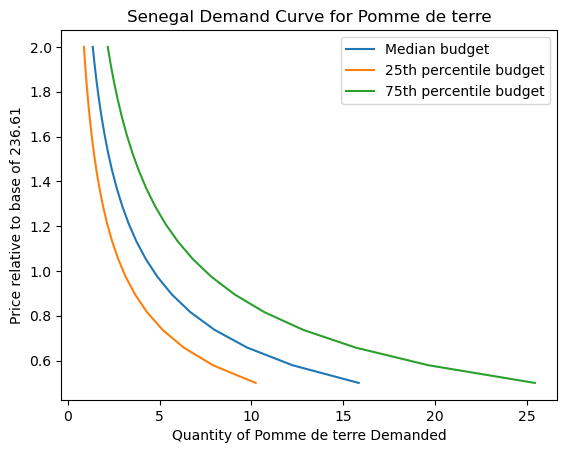

In [34]:
SE_use = 'Pomme de terre'

scale = np.linspace(0.5, 2, 20)

plt.plot(
    [SE_result.demands(SE_xref, my_prices(SE_pbar[SE_use] * s, SE_pbar, SE_use))[SE_use] for s in scale],
    scale
)

plt.plot(
    [SE_result.demands(SE_xbar.quantile(0.25), my_prices(SE_pbar[SE_use] * s, SE_pbar, SE_use))[SE_use] for s in scale],
    scale
)

plt.plot(
    [SE_result.demands(SE_xbar.quantile(0.75), my_prices(SE_pbar[SE_use] * s, SE_pbar, SE_use))[SE_use] for s in scale],
    scale
)

plt.ylabel(f"Price relative to base of {SE_pbar[SE_use]:.2f}")
plt.xlabel(f"Quantity of {SE_use} Demanded")
plt.title(f"Senegal Demand Curve for {SE_use}")
plt.legend(["Median budget", "25th percentile budget", "75th percentile budget"])
plt.show()

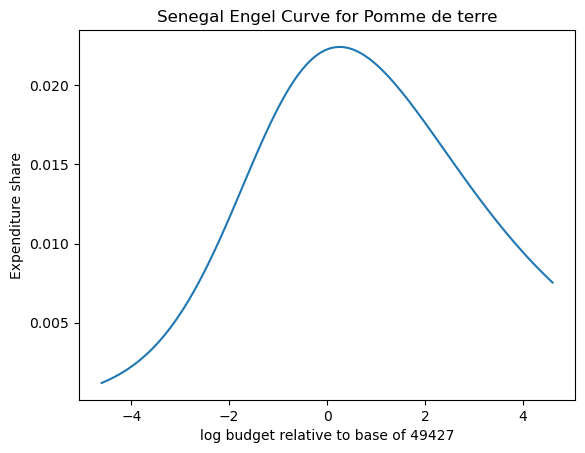

In [35]:
fig, ax = plt.subplots()

SE_use = 'Pomme de terre'
scale = np.geomspace(0.01, 100, 100)

ax.plot(
    np.log(scale),
    [(SE_result.expenditures(s * SE_xref, SE_pbar) / (s * SE_xref))[SE_use] for s in scale]
)

ax.set_xlabel(f"log budget relative to base of {SE_xref:.0f}")
ax.set_ylabel("Expenditure share")
ax.set_title(f"Senegal Engel Curve for {SE_use}")
plt.show()

#### Interpretation of Senegal Curves for Pomme de terre (Potatoes)

Demad Curve: 
- For Senegal potatoes, the higher-budget household demands noticeably more potatoes than the median- and lower-budget households.
- This suggests potato demand is positively related to household resources.
- In simple terms: when households have more money to spend, they can buy more potatoes, even when prices are the same.

Engel Curve: 
- The expenditure share for potatoes increases at first, reaches a peak around the middle budget range, and then declines as budgets keep rising.
- This suggests potatoes are important for households as their budgets improve, but at higher budgets, households likely shift part of their spending toward a wider variety of foods.
- So potatoes are not a pure luxury good, but they also do not keep taking a larger share of the budget forever.

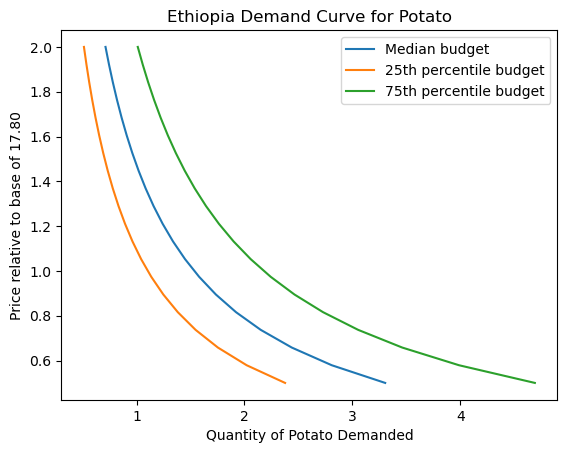

In [36]:
ET_use = 'Potato'

scale = np.linspace(0.5, 2, 20)

plt.plot(
    [ET_result.demands(ET_xref, my_prices(ET_pbar[ET_use] * s, ET_pbar, ET_use))[ET_use] for s in scale],
    scale
)

plt.plot(
    [ET_result.demands(ET_xbar.quantile(0.25), my_prices(ET_pbar[ET_use] * s, ET_pbar, ET_use))[ET_use] for s in scale],
    scale
)

plt.plot(
    [ET_result.demands(ET_xbar.quantile(0.75), my_prices(ET_pbar[ET_use] * s, ET_pbar, ET_use))[ET_use] for s in scale],
    scale
)

plt.ylabel(f"Price relative to base of {ET_pbar[ET_use]:.2f}")
plt.xlabel(f"Quantity of {ET_use} Demanded")
plt.title(f"Ethiopia Demand Curve for {ET_use}")
plt.legend(["Median budget", "25th percentile budget", "75th percentile budget"])
plt.show()

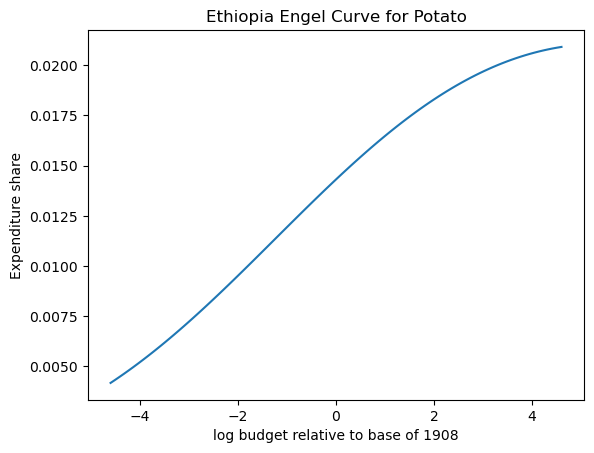

In [37]:
fig, ax = plt.subplots()

ET_use = 'Potato'
scale = np.geomspace(0.01, 100, 100)

ax.plot(
    np.log(scale),
    [(ET_result.expenditures(s * ET_xref, ET_pbar) / (s * ET_xref))[ET_use] for s in scale]
)

ax.set_xlabel(f"log budget relative to base of {ET_xref:.0f}")
ax.set_ylabel("Expenditure share")
ax.set_title(f"Ethiopia Engel Curve for {ET_use}")
plt.show()

#### Interpretation of Ethiopia Curves for Potatoes
                                           
Demand Curve:
- The demand curve is still downward sloping, which means that as the price of potatoes rises, the quantity demanded falls.
- The 75th percentile budget curve lies farthest to the right, followed by the median budget and then the 25th percentile budget curve.
- This means that households with higher budgets demand more potatoes at any given price.
                                           
Engel Curve:
- Unlike the earlier curve, this Engel curve is not hump-shaped.
- Instead, it is upward sloping, though it starts to flatten a little at higher budget levels.
- This means that as household budget increases, the share of expenditure spent on potatoes also increases.
- In simple terms, richer households tend to devote a larger share of their food budget to potatoes.
- Since it does not turn downward, this suggests potatoes may become more important in the food basket as income rises, rather than being replaced by many other foods at higher budget levels.